In [18]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

import warnings
warnings.filterwarnings("ignore")

Load Processed Dataset

In [19]:
df = pd.read_csv(
    "../data/processed/processed_walmart_sales.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(6435, 15)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Day,DayOfWeek,WeekendFlag
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1,5,4,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1,12,4,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1,19,4,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1,26,4,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,5,4,0


### Create Festival Calendar

Since Walmart data spans 2010–2012, we'll use major retail-impact festivals/holidays.

In [48]:
festival_calendar = {

    # ==========================
    # 2010
    # ==========================
    pd.Timestamp("2010-01-01"): ("New_Year", 7),
    pd.Timestamp("2010-02-14"): ("Valentines_Day", 6),
    pd.Timestamp("2010-03-01"): ("Holi", 8),
    pd.Timestamp("2010-04-04"): ("Easter", 6),
    pd.Timestamp("2010-07-04"): ("Independence_Day", 7),
    pd.Timestamp("2010-08-24"): ("Raksha_Bandhan", 7),
    pd.Timestamp("2010-09-06"): ("Labor_Day", 7),
    pd.Timestamp("2010-09-11"): ("Ganesh_Chaturthi", 8),
    pd.Timestamp("2010-09-17"): ("Janmashtami", 7),
    pd.Timestamp("2010-10-17"): ("Dussehra", 9),
    pd.Timestamp("2010-10-31"): ("Halloween", 6),
    pd.Timestamp("2010-11-05"): ("Diwali", 10),
    pd.Timestamp("2010-11-25"): ("Thanksgiving", 9),
    pd.Timestamp("2010-11-26"): ("Black_Friday", 10),
    pd.Timestamp("2010-12-25"): ("Christmas", 8),

    # ==========================
    # 2011
    # ==========================
    pd.Timestamp("2011-01-01"): ("New_Year", 7),
    pd.Timestamp("2011-02-14"): ("Valentines_Day", 6),
    pd.Timestamp("2011-03-20"): ("Holi", 8),
    pd.Timestamp("2011-04-24"): ("Easter", 6),
    pd.Timestamp("2011-07-04"): ("Independence_Day", 7),
    pd.Timestamp("2011-08-13"): ("Raksha_Bandhan", 7),
    pd.Timestamp("2011-08-22"): ("Janmashtami", 7),
    pd.Timestamp("2011-09-01"): ("Ganesh_Chaturthi", 8),
    pd.Timestamp("2011-09-05"): ("Labor_Day", 7),
    pd.Timestamp("2011-10-06"): ("Dussehra", 9),
    pd.Timestamp("2011-10-26"): ("Diwali", 10),
    pd.Timestamp("2011-10-31"): ("Halloween", 6),
    pd.Timestamp("2011-11-24"): ("Thanksgiving", 9),
    pd.Timestamp("2011-11-25"): ("Black_Friday", 10),
    pd.Timestamp("2011-12-25"): ("Christmas", 8),

    # ==========================
    # 2012
    # ==========================
    pd.Timestamp("2012-01-01"): ("New_Year", 7),
    pd.Timestamp("2012-02-14"): ("Valentines_Day", 6),
    pd.Timestamp("2012-03-08"): ("Holi", 8),
    pd.Timestamp("2012-04-08"): ("Easter", 6),
    pd.Timestamp("2012-07-04"): ("Independence_Day", 7),
    pd.Timestamp("2012-08-02"): ("Raksha_Bandhan", 7),
    pd.Timestamp("2012-08-10"): ("Janmashtami", 7),
    pd.Timestamp("2012-09-03"): ("Labor_Day", 7),
    pd.Timestamp("2012-09-19"): ("Ganesh_Chaturthi", 8),
    pd.Timestamp("2012-10-24"): ("Dussehra", 9),
    pd.Timestamp("2012-10-31"): ("Halloween", 6),
    pd.Timestamp("2012-11-13"): ("Diwali", 10),
    pd.Timestamp("2012-11-22"): ("Thanksgiving", 9),
    pd.Timestamp("2012-11-23"): ("Black_Friday", 10),
    pd.Timestamp("2012-12-25"): ("Christmas", 8)
}

In [49]:
festival_calendar = {
    pd.to_datetime(k): v
    for k, v in festival_calendar.items()
}

Initialize Festival Columns

In [50]:
df["Festival_Flag"] = 0

df["Festival_Name"] = "None"

df["Festival_Score"] = 0

df["Days_To_Festival"] = np.nan

df["Festival_Week"] = 0

df["Festival_Month"] = 0

df["Festival_Impact_Score"] = 0

df["Pre_Festival_Flag"] = 0

df["Post_Festival_Flag"] = 0

Assign Festival Information

In [51]:
for festival_date, values in festival_calendar.items():

    festival_name = values[0]
    festival_score = values[1]

    start_date = festival_date - timedelta(days=7)
    end_date = festival_date + timedelta(days=7)

    mask = (
        (df["Date"] >= start_date)
        &
        (df["Date"] <= end_date)
    )

    df.loc[mask, "Festival_Flag"] = 1

    df.loc[mask, "Festival_Name"] = festival_name

    df.loc[mask, "Festival_Score"] = festival_score

    df.loc[mask, "Festival_Week"] = festival_date.isocalendar().week

    df.loc[mask, "Festival_Month"] = festival_date.month

### Create Days_To_Festival Feature

For every row, find nearest festival.

In [52]:
festival_dates = list(festival_calendar.keys())

days_list = []

for current_date in df["Date"]:

    nearest = min(
        festival_dates,
        key=lambda x: abs((x - current_date).days)
    )

    days = abs(
        (nearest - current_date).days
    )

    days_list.append(days)

df["Days_To_Festival"] = days_list

### Pre-Festival Window

7 days before festival.

In [53]:
for festival_date in festival_dates:

    start_date = festival_date - timedelta(days=7)

    mask = (
        (df["Date"] >= start_date)
        &
        (df["Date"] < festival_date)
    )

    df.loc[
        mask,
        "Pre_Festival_Flag"
    ] = 1

### Post-Festival Window

7 days after festival.

In [54]:
for festival_date in festival_dates:

    end_date = festival_date + timedelta(days=7)

    mask = (
        (df["Date"] > festival_date)
        &
        (df["Date"] <= end_date)
    )

    df.loc[
        mask,
        "Post_Festival_Flag"
    ] = 1

### Dynamic Festival Impact Score

Higher score near festivals.

In [55]:
df["Festival_Impact_Score"] = (
    df["Festival_Score"]
    +
    (30 - df["Days_To_Festival"])
      .clip(lower=0)
)

Verify Features

In [56]:
festival_columns = [

    "Date",

    "Festival_Flag",

    "Festival_Name",

    "Festival_Score",

    "Days_To_Festival",

    "Festival_Week",

    "Festival_Month",

    "Festival_Impact_Score",

    "Pre_Festival_Flag",

    "Post_Festival_Flag"
]

df[festival_columns].sample(20)

,Date,Festival_Flag,Festival_Name,Festival_Score,Days_To_Festival,Festival_Week,Festival_Month,Festival_Impact_Score,Pre_Festival_Flag,Post_Festival_Flag
1784,2011-05-27,0,None,0,33,0,0,0,0,0
378,2011-11-11,0,None,0,11,0,0,19,0,0
5813,2011-11-18,1,Black_Friday,10,6,47,11,34,1,0
641,2011-06-03,0,None,0,31,0,0,0,0,0
1527,2011-12-16,0,None,0,9,0,0,21,0,0
5295,2010-03-05,1,Holi,8,4,9,3,34,0,1
4998,2012-09-14,1,Ganesh_Chaturthi,8,5,38,9,33,1,0
1437,2010-03-26,0,None,0,9,0,0,21,0,0
2930,2011-06-10,0,None,0,24,0,0,6,0,0
156,2010-05-07,0,None,0,33,0,0,0,0,0


Festival Counts

In [57]:
df["Festival_Name"].value_counts()

Festival_Name
None                3420
Janmashtami          315
Valentines_Day       270
Easter               270
Independence_Day     270
Black_Friday         270
Holi                 270
Dussehra             225
Labor_Day            225
Raksha_Bandhan       180
Diwali               180
New_Year             180
Ganesh_Chaturthi     135
Halloween            135
Christmas             90
Name: count, dtype: int64

Festival Sales Analysis

In [44]:
festival_sales = df.groupby(
    "Festival_Name"
)["Weekly_Sales"].mean()

festival_sales.sort_values(
    ascending=False
)

Festival_Name
Christmas           1.754774e+06
Black_Friday        1.197329e+06
Valentines_Day      1.084713e+06
Easter              1.074546e+06
Independence_Day    1.074463e+06
Labor_Day           1.038734e+06
None                1.023704e+06
Halloween           1.019735e+06
New_Year            9.678122e+05
Name: Weekly_Sales, dtype: float64

Visualization

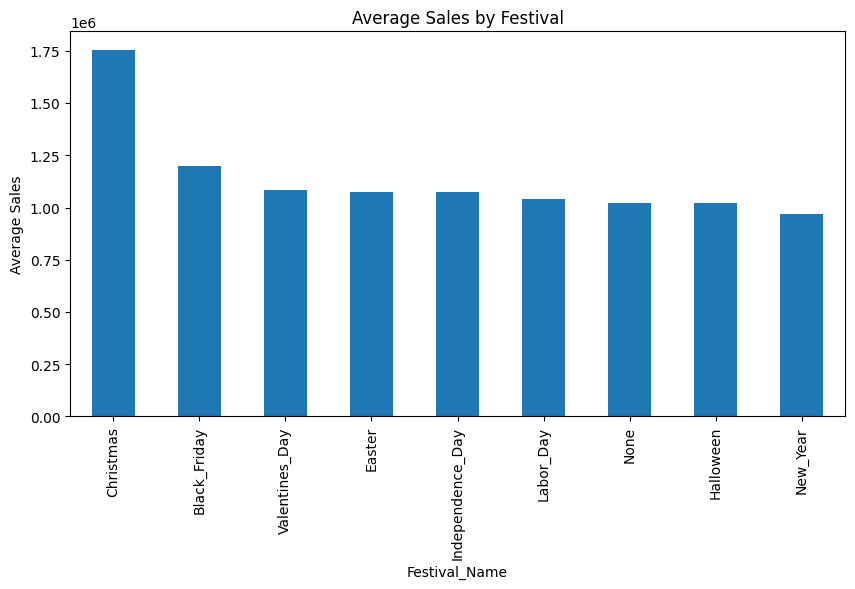

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

festival_sales.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title(
    "Average Sales by Festival"
)

plt.ylabel("Average Sales")

plt.show()

Save Dataset

In [46]:
df.to_csv(
    "../data/processed/festival_enriched_sales.csv",
    index=False
)

print(
    "Festival enriched dataset saved successfully!"
)

Festival enriched dataset saved successfully!
